In [10]:
import nmrglue as ng
import pandas as pd
import matplotlib.pyplot as plt

#### **Objective: Unbin H8 Data to confirm viablity**

In [4]:
# Path to the processed data (pdata/1)
path = "data/400MHz/H8/10/pdata/1"

# Read processed spectrum
dic, data = ng.bruker.read_pdata(path)   # data will be a 1D array (real part from 1r)

In [6]:
# Step 2: Create a units converter for the ppm scale
udic = ng.bruker.guess_udic(dic, data)
uc = ng.fileiobase.uc_from_udic(udic)


In [7]:
# Step 3: Generate the full ppm scale and export
ppm_scale = uc.ppm_scale()
df = pd.DataFrame({"ppm": ppm_scale, "intensity": data})
df.to_csv("H8_unbinned_spectrum.csv", index=False)

print(f"Success! Unbinned spectrum saved with {len(data)} points.")

Success! Unbinned spectrum saved with 65536 points.


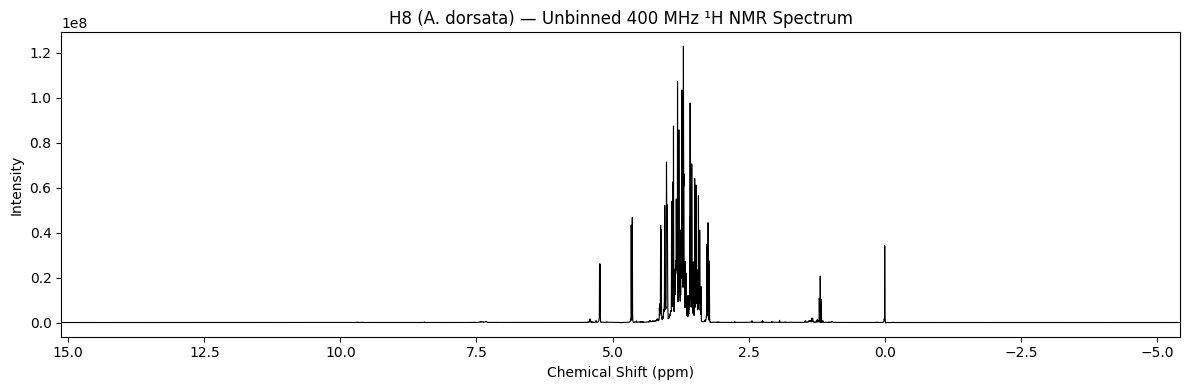

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(ppm_scale, data, linewidth=0.8, color='black')
plt.xlabel('Chemical Shift (ppm)')
plt.ylabel('Intensity')
plt.title('H8 (A. dorsata) — Unbinned 400 MHz ¹H NMR Spectrum')
plt.xlim(max(ppm_scale), min(ppm_scale))  # NMR convention: right to left
plt.tight_layout()
plt.savefig('H8_unbinned_spectrum.png', dpi=150)
plt.show()